In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model


### Cargamos el dataset

In [2]:
df = pd.read_csv('../Data/titanic.csv')
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df = pd.get_dummies(df)
del df['Sex_female']
df['Age'] = df['Age'].fillna(df.Age.mean())

### Creamos un modelo

In [3]:
target = 'Survived'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

model=linear_model.LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [4]:
predicciones=model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_pred=predicciones,y_true=y_test)

0.8022388059701493

### Matriz de confusion

|                     | **Predicho Positivo** | **Predicho Negativo** |
|---------------------|-----------------------|-----------------------|
| **Real Positivo**   | True Positives (TP) | False Negatives (FN) |
| **Real Negativo**   | False Positives (FP) | True Negatives (TN) |


- TP (Verdaderos Positivos): Casos positivos correctamente clasificados.

- FN (Falsos Negativos): Casos positivos incorrectamente clasificados como negativos.

- FP (Falsos Positivos): Casos negativos incorrectamente clasificados como positivos.

- TN (Verdaderos Negativos): Casos negativos correctamente clasificados.

In [5]:
# Crea una matriz de confusión con Sklearn
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_pred=predicciones,y_true=y_test)


### Sensitivity 

Dentro de los que si sobreviven, que porcentaje predice bien el modelo

|                     | **Predicho Positivo** | **Predicho Negativo** |
|---------------------|-----------------------|-----------------------|
| **Real Positivo**   | True Positives (TP) | False Negatives (FN) |
| **Real Negativo**   | False Positives (FP) | True Negatives (TN) |


$$\text{Sensitivity} = \frac{\text{True positive (TP)}}{\text{True positive (TP)} + \text{False Negative (FN)}}$$

In [6]:
cf_matrix[0][0]/(cf_matrix[0][0]+cf_matrix[0][1]) # True Negatives / (True Negatives + False Positives)


np.float64(0.8511904761904762)

### Especificidad 

De los que no sobreviven, que porcentaje predice bien el modelo 

|                     | **Predicho Positivo** | **Predicho Negativo** |
|---------------------|-----------------------|-----------------------|
| **Real Positivo**   | True Positives (TP) | False Negatives (FN) |
| **Real Negativo**   | False Positives (FP) | True Negatives (TN) |


$$\text{Specificity} = \frac{\text{True Negative (TN)}}{\text{True Negative (TN)} + \text{False Positive (FP)}}$$


In [7]:
cf_matrix[1][1]/(cf_matrix[1][0]+cf_matrix[1][1]) # True Positives / (True Positives + False Negatives)

np.float64(0.72)

### Recrea la matriz de confusión, calcula sensitivity y specificity con un corte de 0.7

In [8]:
probabilidades=model.predict_proba(X_test)[:, 1] # Probabilidades de la clase positiva
predicciones_07=np.where(probabilidades>0.7, True, False) # Predicciones con umbral de 0.7

In [9]:
cf_matrix1 = confusion_matrix(y_pred=predicciones_07,y_true=y_test)

In [10]:
# Sensitivity = TP / (TP + FN)
cf_matrix1[0][0]/(cf_matrix1[0][0]+cf_matrix1[0][1]) # True Negatives / (True Negatives + False Positives)


np.float64(0.9702380952380952)

In [11]:
# Specificity = TN / (TN + FP)
cf_matrix1[1][1]/(cf_matrix1[1][0]+cf_matrix1[1][1]) # True Positives / (True Positives + False Negatives)

np.float64(0.5)

### Siempre habrá un balance entre sensitivity y specificity en la elección de los cortes 



### Utiliza sklearn para obtener esta curva

In [12]:
from sklearn.metrics import roc_curve
fpr, tpr, umbrales = roc_curve(y_true=y_test, y_score=probabilidades)


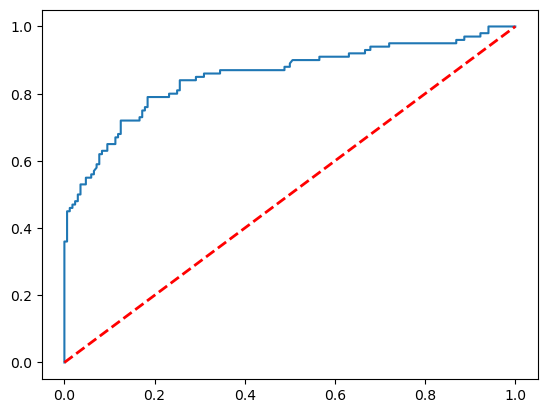

In [13]:
# fpr, tpr
plt.plot(fpr,tpr)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

### Definición, el AUC es el área del gráfico anterior que está bajo la linea (área bajo la curva)

Si se toman dos datos al azar, uno que sobrevive y otro que no sobrevive, ¿cuál es la probabilidad de que el que sobrevive tenga mayor probabilidad predicha?



In [14]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_true=y_test, y_score=probabilidades)

np.float64(0.8526190476190476)

### Calcula el AUC de una regresión polinomial grado 2

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV



### Compara las dos ROC curves

### KNN clasificación, cross validation de vecions más cercanos con AUC

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:


model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)


KNeighborsClassifier()

In [18]:
knn_prob=model_knn.predict_proba(X_test)[:, 1]


In [19]:
roc_auc_score(y_score=knn_prob,y_true=y_test)

np.float64(0.7369940476190477)

In [20]:
fpr_knn, tpr_knn, umbrales = roc_curve(y_true=y_test, y_score=knn_prob)

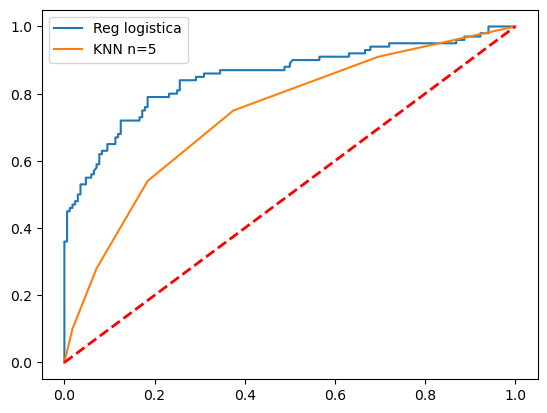

In [21]:
#fpr, tpr
plt.plot(fpr,tpr,label="Reg logistica")
plt.plot(fpr_knn, tpr_knn, label="KNN n=5")
plt.legend()
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

## Intuitivamente, que es el AUC

Si tomas dos personas, una que sobrevive y otra que no

*El AUC es la probabilidad de que la persona que sobrevive, tiene una predicción más alta*




In [30]:
auc_df=pd.DataFrame({
    'prob':probabilidades,
    'prob_knn':knn_prob,
    'y_test':y_test
})
resultado=[]
for i in range (1,1000):
    no_sobrevive_al_azar=auc_df.query('y_test==0').sample(1)
    sobrevive_al_azar=auc_df.query('y_test==1').sample(1)

    #score no sobrevive
    score_mayor=sobrevive_al_azar.prob.values[0]>no_sobrevive_al_azar.prob.values[0]

    #guardamos el resultado 
    resultado.append(score_mayor)



In [31]:
np.mean(resultado)

np.float64(0.8578578578578578)